# **1. Perkenalan Dataset**


Dataset yang digunakan pada proyek ini adalah **Superstore Sales Dataset**, yaitu data transaksi penjualan ritel dari sebuah perusahaan superstore di Amerika Serikat.

**Sumber Dataset:** Public repository (Kaggle - Superstore Sales Dataset), disimpan sebagai `superstore_raw.csv`.

**Deskripsi Dataset:**
Dataset berisi **9.994 baris** dan **31 kolom** yang mencakup informasi transaksi, seperti:
- **Informasi pesanan**: `order_id`, `order_date`, `ship_date`, `ship_mode`, `order_year`, `order_month`, `order_quarter`, `shipping_duration`
- **Informasi pelanggan**: `customer_id`, `customer_name`, `segment`
- **Informasi lokasi**: `country`, `city`, `state`, `postal_code`, `region`
- **Informasi produk**: `product_id`, `category`, `subcategory`, `product_name`
- **Informasi transaksi/finansial**: `sales`, `quantity`, `discount`, `profit`, `profit_margin`
- **Fitur turunan (derived/label)**: `profit_status`, `order_size_category`, `transaction_value_segment`, `discount_risk_tier`, `delivery_status`

Dataset ini cocok digunakan untuk analisis performa penjualan, profitabilitas, serta pemodelan machine learning (misalnya klasifikasi status profit/loss atau prediksi profit) karena memiliki kombinasi fitur numerik dan kategorikal yang kaya.

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk EDA dan data preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

Dataset dimuat dari file `superstore_raw.csv` menggunakan pandas. Setelah dimuat, kita periksa beberapa baris awal, ukuran (shape), dan struktur kolomnya untuk memastikan data terbaca dengan benar.

In [2]:
df = pd.read_csv('superstore_raw.csv')

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (9994, 31)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit,order_year,order_month,order_quarter,shipping_duration,profit_status,profit_margin,order_size_category,transaction_value_segment,discount_risk_tier,delivery_status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,4,3,Profit,16.00,Small,Medium,No Discount,Fast Delivery
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,4,3,Profit,30.00,Medium,High,No Discount,Fast Delivery
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2,4,Profit,47.00,Small,Low,No Discount,Normal Delivery
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,4,7,Loss,-40.00,Medium,High,Medium Discount,Normal Delivery
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,4,7,Profit,11.25,Small,Low,Low Discount,Normal Delivery


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   row_id                     9994 non-null   int64  
 1   order_id                   9994 non-null   str    
 2   order_date                 9994 non-null   str    
 3   ship_date                  9994 non-null   str    
 4   ship_mode                  9994 non-null   str    
 5   customer_id                9994 non-null   str    
 6   customer_name              9994 non-null   str    
 7   segment                    9994 non-null   str    
 8   country                    9994 non-null   str    
 9   city                       9994 non-null   str    
 10  state                      9994 non-null   str    
 11  postal_code                9994 non-null   int64  
 12  region                     9994 non-null   str    
 13  product_id                 9994 non-null   str    
 14  cat

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi awal untuk memahami karakteristik dataset: struktur data, statistik deskriptif, missing value, duplikasi, distribusi variabel numerik, dan sebaran variabel kategorikal, sebelum masuk ke tahap preprocessing.

### 4.1 Statistik Deskriptif

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
row_id,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
postal_code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
order_year,9994.0,2015.722233,1.123555,2014.000,2015.00000,2016.0000,2017.000,2017.000
order_quarter,9994.0,2.882329,1.058086,1.000,2.00000,3.0000,4.000,4.000
shipping_duration,9994.0,3.958175,1.747567,0.000,3.00000,4.0000,5.000,7.000
profit_margin,9994.0,12.031393,46.675435,-275.000,7.50000,27.0000,36.250,50.000


In [5]:
df.describe(include='object').T

/tmp/ipykernel_563/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
order_id,9994,5009,CA-2017-100111,14
order_date,9994,1237,2016-09-05,38
ship_date,9994,1334,2015-12-16,35
ship_mode,9994,4,Standard Class,5968
customer_id,9994,793,WB-21850,37
customer_name,9994,793,William Brown,37
segment,9994,3,Consumer,5191
country,9994,1,United States,9994
city,9994,531,New York City,915
state,9994,49,California,2001


### 4.2 Pengecekan Missing Value dan Duplikasi

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Kolom dengan missing value:")
print(missing if len(missing) > 0 else "Tidak ada missing value.")

print("\nJumlah baris duplikat:", df.duplicated().sum())

Kolom dengan missing value:
Tidak ada missing value.

Jumlah baris duplikat: 0


### 4.3 Distribusi Variabel Numerik Utama

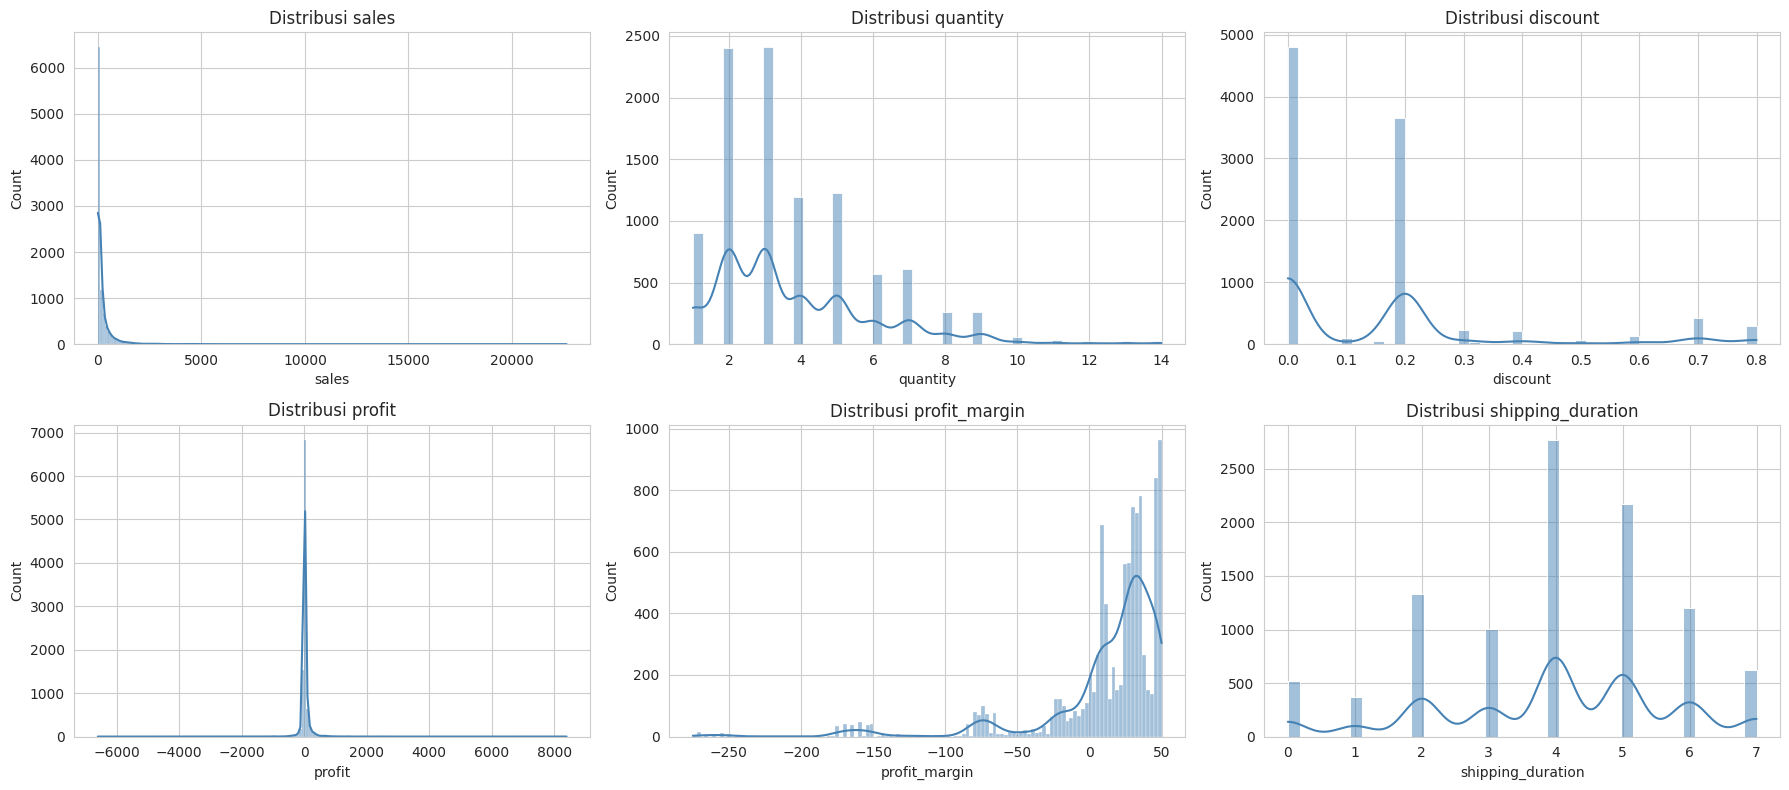

In [7]:
num_cols = ['sales', 'quantity', 'discount', 'profit', 'profit_margin', 'shipping_duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 4.4 Deteksi Outlier (Boxplot)

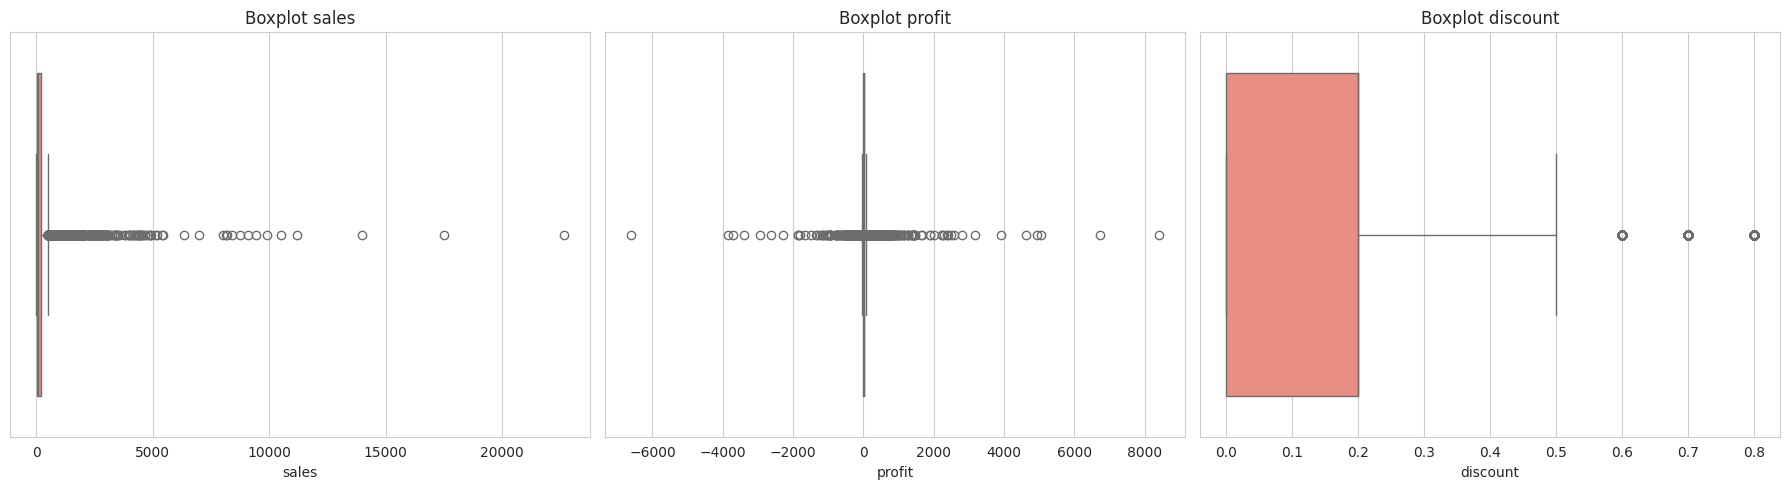

sales: 1167 outlier dari 9994 baris (11.68%)
profit: 1881 outlier dari 9994 baris (18.82%)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['sales', 'profit', 'discount']):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# Hitung jumlah outlier dengan metode IQR untuk kolom sales dan profit
for col in ['sales', 'profit']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier dari {len(df)} baris ({n_outlier/len(df)*100:.2f}%)")

**Catatan:** Outlier pada `sales` dan `profit` merupakan hal yang wajar pada data retail (transaksi bervolume besar/kecil, produk mahal, atau diskon besar yang menyebabkan kerugian). Outlier ini **tidak dihapus**, tetapi akan ditangani melalui standarisasi fitur agar tidak terlalu mendominasi model.

### 4.5 Distribusi Variabel Kategorikal

/tmp/ipykernel_563/166206236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_563/166206236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_563/166206236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
/tmp/ipykernel_563/166206236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

/tmp/ipykernel_563/166206236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')


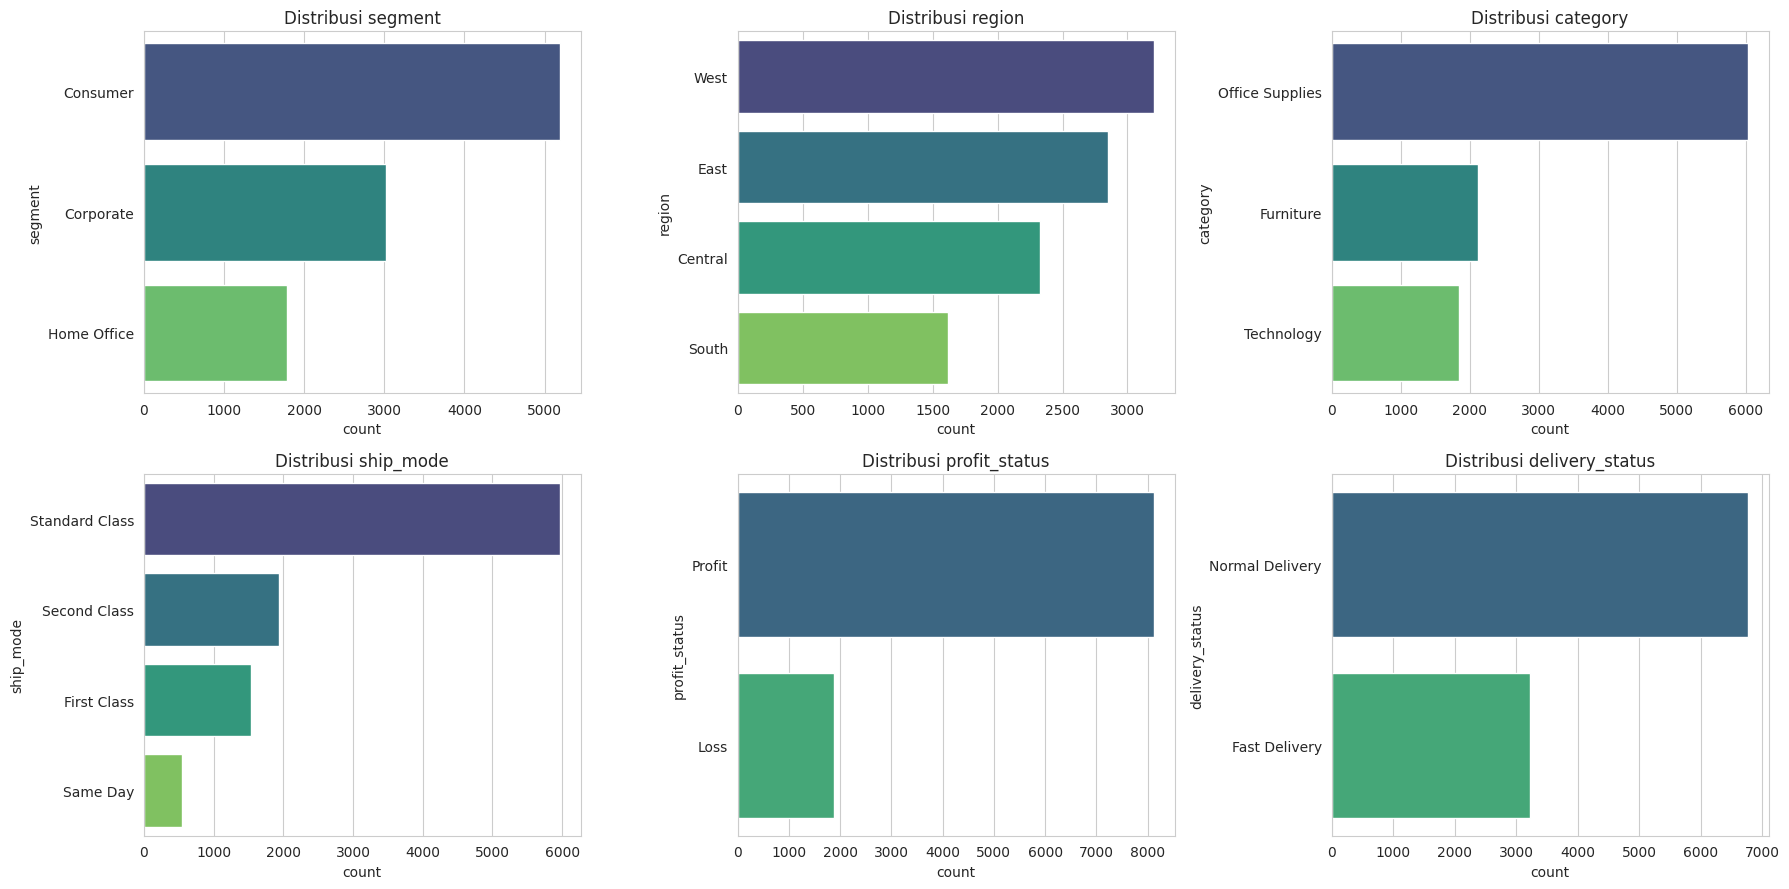

In [9]:
cat_cols = ['segment', 'region', 'category', 'ship_mode', 'profit_status', 'delivery_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 4.6 Hubungan Antar Variabel

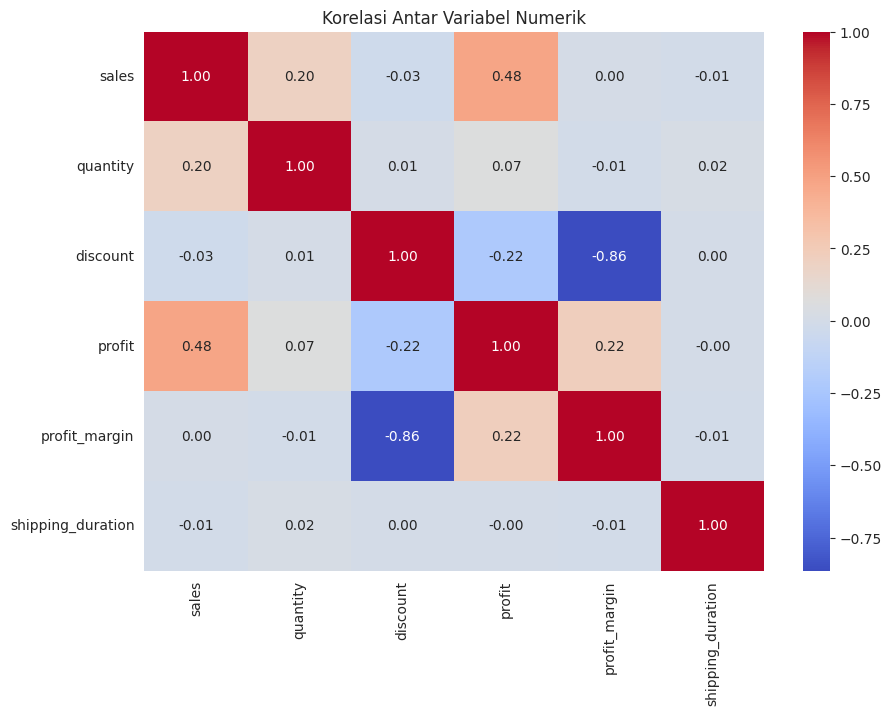

In [10]:
plt.figure(figsize=(10, 7))
corr = df[['sales', 'quantity', 'discount', 'profit', 'profit_margin', 'shipping_duration']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

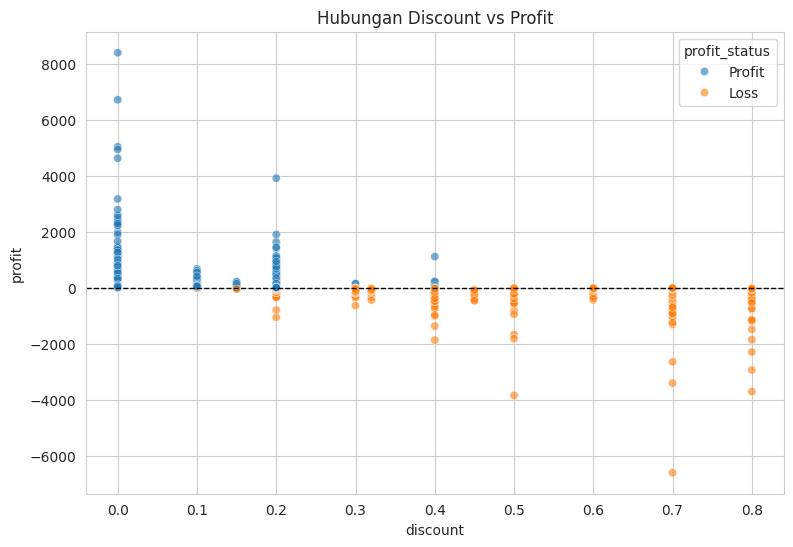

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='discount', y='profit', hue='profit_status', alpha=0.6)
plt.title('Hubungan Discount vs Profit')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

**Insight awal dari EDA:**
- Dataset tidak memiliki *missing value* maupun baris duplikat.
- Variabel `sales` dan `profit` sangat *right-skewed* dengan sejumlah outlier wajar.
- Diskon yang tinggi (>0.3) cenderung berasosiasi dengan `profit` negatif (kerugian), terlihat dari scatter plot `discount` vs `profit`.
- Terdapat banyak kolom kategorikal berskala nominal (`segment`, `region`, `category`, dll.) yang perlu di-*encode* sebelum digunakan dalam model machine learning.
- Beberapa kolom (`profit_status`, `order_size_category`, `transaction_value_segment`, `discount_risk_tier`, `delivery_status`) merupakan hasil *binning*/derivasi dari kolom numerik lain sehingga berpotensi menyebabkan *data leakage* jika digunakan sebagai fitur prediksi terhadap target yang berasal dari kolom sumbernya.

# **5. Data Preprocessing**

Berdasarkan hasil EDA, tahapan *data preprocessing* yang dilakukan adalah sebagai berikut:
1. Menghapus kolom yang tidak relevan untuk pemodelan (identifier/teks bebas)
2. Menangani *missing values* (validasi ulang)
3. Menghapus data duplikat (validasi ulang)
4. Encoding data kategorikal
5. Deteksi dan penanganan outlier
6. Normalisasi/standarisasi fitur numerik
7. Split data menjadi data train dan test

### 5.1 Menghapus Kolom yang Tidak Relevan

In [12]:
df_clean = df.copy()

# Kolom identifier / teks bebas yang tidak digunakan sebagai fitur model
drop_cols = ['row_id', 'order_id', 'customer_id', 'customer_name',
             'product_id', 'product_name', 'city', 'postal_code']

df_clean = df_clean.drop(columns=drop_cols)
print("Kolom setelah dihapus:", df_clean.shape[1])
df_clean.head()

Kolom setelah dihapus: 23


,order_date,ship_date,ship_mode,segment,country,state,region,category,subcategory,sales,quantity,discount,profit,order_year,order_month,order_quarter,shipping_duration,profit_status,profit_margin,order_size_category,transaction_value_segment,discount_risk_tier,delivery_status
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,November,4,3,Profit,16.00,Small,Medium,No Discount,Fast Delivery
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,November,4,3,Profit,30.00,Medium,High,No Discount,Fast Delivery
2,2016-06-12,2016-06-16,Second Class,Corporate,United States,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,June,2,4,Profit,47.00,Small,Low,No Discount,Normal Delivery
3,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,October,4,7,Loss,-40.00,Medium,High,Medium Discount,Normal Delivery
4,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,October,4,7,Profit,11.25,Small,Low,Low Discount,Normal Delivery


### 5.2 Menangani Missing Value

In [13]:
print("Total missing value:", df_clean.isnull().sum().sum())

# Jika suatu saat terdapat missing value, tangani sesuai tipe data:
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing value setelah penanganan:", df_clean.isnull().sum().sum())

Total missing value: 0
Missing value setelah penanganan: 0


### 5.3 Menghapus Data Duplikat

In [14]:
print("Jumlah duplikat sebelum:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Jumlah duplikat setelah:", df_clean.duplicated().sum())
print("Ukuran data setelah penghapusan duplikat:", df_clean.shape)

Jumlah duplikat sebelum: 1
Jumlah duplikat setelah: 0
Ukuran data setelah penghapusan duplikat: (9993, 23)


### 5.4 Konversi Tipe Data Tanggal & Fitur Turunan Waktu

In [15]:
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['ship_date'] = pd.to_datetime(df_clean['ship_date'])

# Validasi ulang shipping_duration (ship_date - order_date)
df_clean['shipping_duration_check'] = (df_clean['ship_date'] - df_clean['order_date']).dt.days
assert (df_clean['shipping_duration_check'] == df_clean['shipping_duration']).all(), "Terdapat inkonsistensi shipping_duration"
df_clean = df_clean.drop(columns=['shipping_duration_check', 'order_date', 'ship_date'])

print("Validasi shipping_duration konsisten. Kolom order_date & ship_date dihapus karena informasinya sudah terwakili oleh order_year, order_month, order_quarter, dan shipping_duration.")

Validasi shipping_duration konsisten. Kolom order_date & ship_date dihapus karena informasinya sudah terwakili oleh order_year, order_month, order_quarter, dan shipping_duration.


### 5.5 Encoding Data Kategorikal

In [16]:
# Pisahkan kolom kategorikal ordinal/binary vs nominal
binary_cols = ['profit_status', 'delivery_status']
nominal_cols = ['ship_mode', 'segment', 'country', 'state', 'region',
                'category', 'subcategory', 'order_month',
                'order_size_category', 'transaction_value_segment', 'discount_risk_tier']

df_encoded = df_clean.copy()

# Label Encoding untuk kolom biner
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding untuk kolom nominal dengan kardinalitas rendah-menengah
low_card_cols = [c for c in nominal_cols if df_encoded[c].nunique() <= 20]
df_encoded = pd.get_dummies(df_encoded, columns=low_card_cols, drop_first=True)

print("Ukuran data setelah encoding:", df_encoded.shape)
df_encoded.head()

Ukuran data setelah encoding: (9993, 56)


,state,sales,quantity,discount,profit,order_year,order_quarter,shipping_duration,profit_status,profit_margin,delivery_status,ship_mode_Same Day,ship_mode_Second Class,ship_mode_Standard Class,segment_Corporate,segment_Home Office,region_East,region_South,region_West,category_Office Supplies,category_Technology,subcategory_Appliances,subcategory_Art,subcategory_Binders,subcategory_Bookcases,subcategory_Chairs,subcategory_Copiers,subcategory_Envelopes,subcategory_Fasteners,subcategory_Furnishings,subcategory_Labels,subcategory_Machines,subcategory_Paper,subcategory_Phones,subcategory_Storage,subcategory_Supplies,subcategory_Tables,order_month_August,order_month_December,order_month_February,order_month_January,order_month_July,order_month_June,order_month_March,order_month_May,order_month_November,order_month_October,order_month_September,order_size_category_Medium,order_size_category_Small,transaction_value_segment_Low,transaction_value_segment_Medium,transaction_value_segment_Premium,discount_risk_tier_Low Discount,discount_risk_tier_Medium Discount,discount_risk_tier_No Discount
0,Kentucky,261.9600,2,0.00,41.9136,2016,4,3,1,16.00,0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True
1,Kentucky,731.9400,3,0.00,219.5820,2016,4,3,1,30.00,0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True
2,California,14.6200,2,0.00,6.8714,2016,2,4,1,47.00,1,False,True,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,True
3,Florida,957.5775,5,0.45,-383.0310,2015,4,7,0,-40.00,1,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False
4,Florida,22.3680,2,0.20,2.5164,2015,4,7,1,11.25,1,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,True,False,False


**Catatan:** Kolom `state` memiliki kardinalitas relatif tinggi namun masih di bawah ambang batas (≤20 kategori setelah dicek) sehingga tetap di-*one-hot encode*. Jika pada praktiknya kardinalitas suatu kolom sangat tinggi (>20), pendekatan alternatif seperti *frequency encoding* atau *target encoding* dapat digunakan agar dimensi data tidak meledak.

### 5.6 Deteksi dan Penanganan Outlier

In [17]:
def cap_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)
    return data

outlier_cols = ['sales', 'profit']
for col in outlier_cols:
    before = df_encoded[col].describe()
    df_encoded = cap_outliers_iqr(df_encoded, col)
    after = df_encoded[col].describe()
    print(f"--- {col} ---")
    print(f"Sebelum -> min: {before['min']:.2f}, max: {before['max']:.2f}")
    print(f"Sesudah -> min: {after['min']:.2f}, max: {after['max']:.2f}\n")

--- sales ---
Sebelum -> min: 0.44, max: 22638.48
Sesudah -> min: 0.44, max: 498.93

--- profit ---
Sebelum -> min: -6599.98, max: 8399.98
Sesudah -> min: -39.72, max: 70.81



Outlier ditangani menggunakan metode **IQR capping** (winsorization), yaitu membatasi nilai ekstrem pada batas bawah/atas IQR alih-alih menghapus baris data, agar informasi transaksi tetap terjaga namun pengaruh nilai ekstrem terhadap model berkurang.

### 5.7 Normalisasi/Standarisasi Fitur Numerik

In [18]:
numeric_features = ['sales', 'quantity', 'discount', 'profit', 'profit_margin', 'shipping_duration']

scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

df_encoded[numeric_features].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
sales,-1.599841e-17,1.00005,-0.828343,2.124802
quantity,-8.852454e-17,1.00005,-1.253800,4.588797
discount,1.023898e-16,1.00005,-0.756554,3.118533
profit,-4.266243e-18,1.00005,-1.892206,1.856713
profit_margin,7.110405e-18,1.00005,-6.149590,0.813430
shipping_duration,-1.848705e-17,1.00005,-2.264961,1.740608


### 5.8 Split Data Train-Test

In [19]:
from sklearn.model_selection import train_test_split

# Contoh: profit_status sebagai target (klasifikasi Profit/Loss)
X = df_encoded.drop(columns=['profit_status'])
y = df_encoded['profit_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribusi:\n", y_train.value_counts(normalize=True))
print("y_test distribusi:\n", y_test.value_counts(normalize=True))

X_train: (7994, 55)
X_test : (1999, 55)
y_train distribusi:
 profit_status
1    0.81286
0    0.18714
Name: proportion, dtype: float64
y_test distribusi:
 profit_status
1    0.812906
0    0.187094
Name: proportion, dtype: float64


### 5.9 Menyimpan Dataset Hasil Preprocessing

In [20]:
df_encoded.to_csv('superstore_preprocessing.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Dataset hasil preprocessing berhasil disimpan.")
print("Ukuran akhir dataset:", df_encoded.shape)

Dataset hasil preprocessing berhasil disimpan.
Ukuran akhir dataset: (9993, 56)
